## 1) PROBLEM STATEMENT

Heart disease is one of the leading causes of death worldwide. Early and accurate detection of heart disease can significantly improve patient survival rates and treatment planning.

The objective of this project is to develop a **Machine Learning classification model** that predicts whether a patient has heart disease based on various medical attributes.

Using patient health indicators such as age, cholesterol level, blood pressure, and other clinical features, this project aims to:

- Perform Exploratory Data Analysis (EDA)
- Clean and preprocess the dataset
- Train multiple classification models
- Evaluate performance using Accuracy, Precision, Recall, and F1-Score
- Select the best-performing model for prediction

This system can assist healthcare professionals in making faster and data-driven diagnostic decisions.

---

## 📊 Data Description

The dataset contains medical records of patients along with a target variable indicating the presence of heart disease.

### 🎯 Target Variable

| Column  | Description |
|----------|-------------|
| target   | 1 = Heart Disease Present, 0 = No Heart Disease |

---

## 🧾 Feature Description

| Feature   | Description |
|------------|-------------|
| age        | Age of the patient (years) |
| sex        | Gender (1 = Male, 0 = Female) |
| cp         | Chest pain type (0–3 categories) |
| trestbps   | Resting blood pressure (mm Hg) |
| chol       | Serum cholesterol (mg/dl) |
| fbs        | Fasting blood sugar > 120 mg/dl (1 = True, 0 = False) |
| restecg    | Resting electrocardiographic results |
| thalach    | Maximum heart rate achieved |
| exang      | Exercise-induced angina (1 = Yes, 0 = No) |
| oldpeak    | ST depression induced by exercise |
| slope      | Slope of peak exercise ST segment |
| ca         | Number of major vessels colored by fluoroscopy |
| thal       | Thalassemia (Normal / Fixed defect / Reversible defect) |

---

## 🤖 Machine Learning Approach

This is a **Supervised Binary Classification** problem:

- **Input (X):** Medical features
- **Output (y):** Heart Disease (0 or 1)

### Algorithms Used

- Logistic Regression
- Decision Tree
- Random Forest


---

## 🎯 Project Goal

- Build a reliable and accurate prediction model
- Minimize false negatives (critical in medical diagnosis)
- Create a deployable model (e.g., using FastAPI)
- Provide insights into important health indicators affecting heart disease

---

## 📈 Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix


# Importing Libraries

In [1]:
#Data Handling

import pandas as pd
import numpy as np

#Visualizing
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

#Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from  sklearn.pipeline import Pipeline


#Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

#Hyper Tunning
from sklearn.model_selection import GridSearchCV , cross_val_score

#Saving 
import joblib


## Understanding Data

In [43]:
url = "https://gist.githubusercontent.com/notreallyme2/8d20f6b5bcc3606e0541cbdf2ee0a7a6/raw/heart.csv"
df = pd.read_csv(url)

print(df.head())


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [45]:
df.shape

(303, 14)

In [46]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [47]:
df.duplicated().sum()

np.int64(1)

In [48]:
df.drop_duplicates(inplace=True)

In [49]:
df.duplicated().sum()

np.int64(0)

## 2) EDA

In [50]:
#Checking target class imbalance 

<Axes: xlabel='target', ylabel='count'>

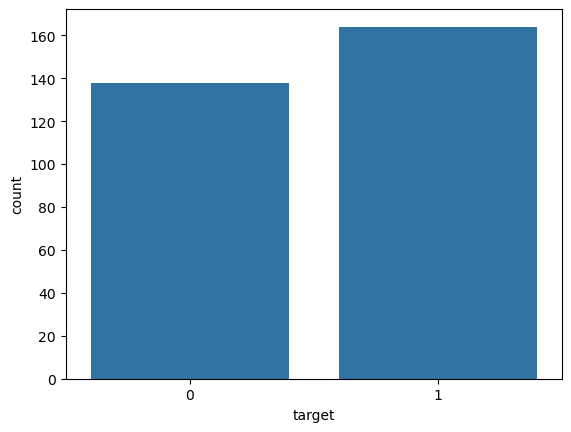

In [51]:
sns.countplot(x=df["target"])

<Axes: xlabel='sex', ylabel='count'>

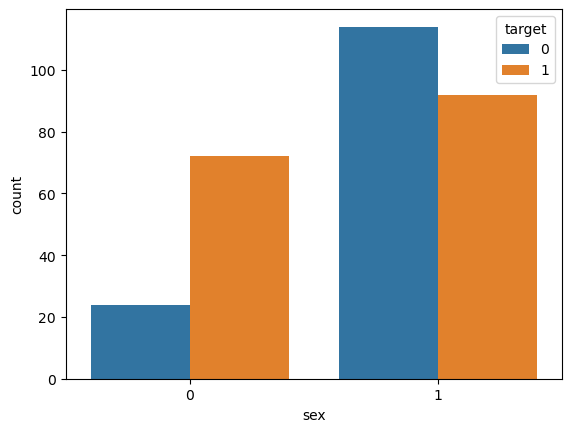

In [52]:
sns.countplot(x=df["sex"], data=df, hue=df["target"])

### As We can See Mostly Women has Heart Disease Then Men 

<Axes: xlabel='cp', ylabel='count'>

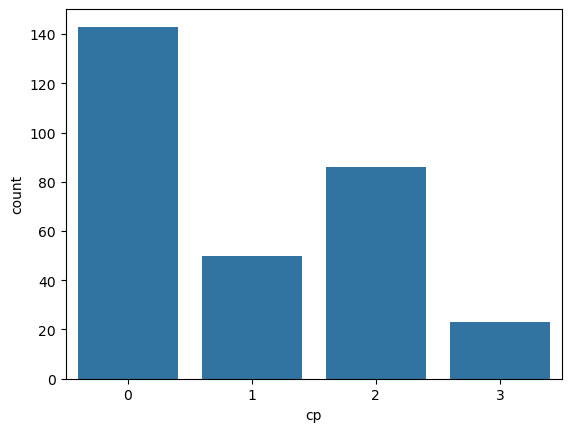

In [53]:
sns.countplot(x=df["cp"] , data=df)

<Axes: xlabel='cp', ylabel='count'>

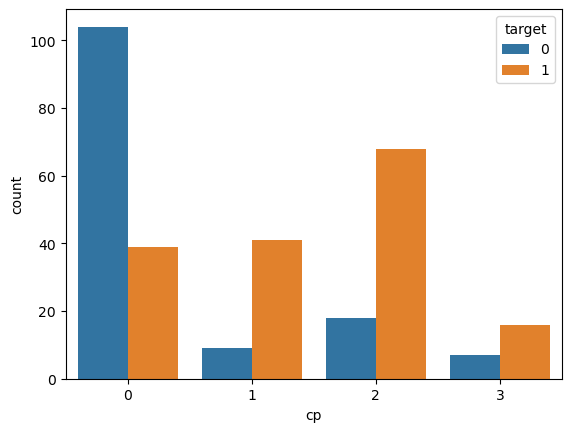

In [54]:
sns.countplot(x=df["cp"] , data=df , hue=df["target"])

### The Chest Type Non-anginal pain patients had more heart disease then the other patients who has other type of pain

In [55]:
# Plotting the hist plot for a all continue values 

In [56]:
features = ["thalach" , "trestbps" , "age" , "chol"]

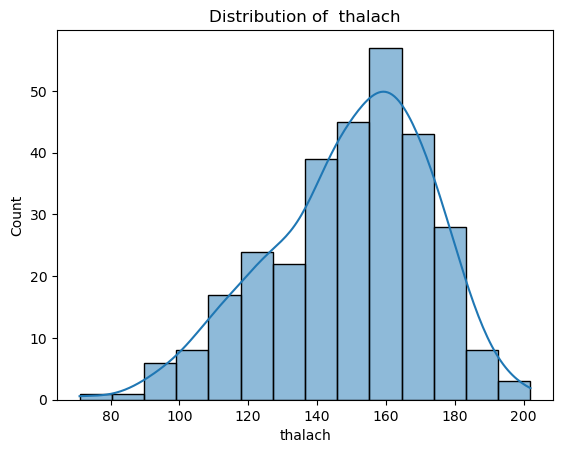

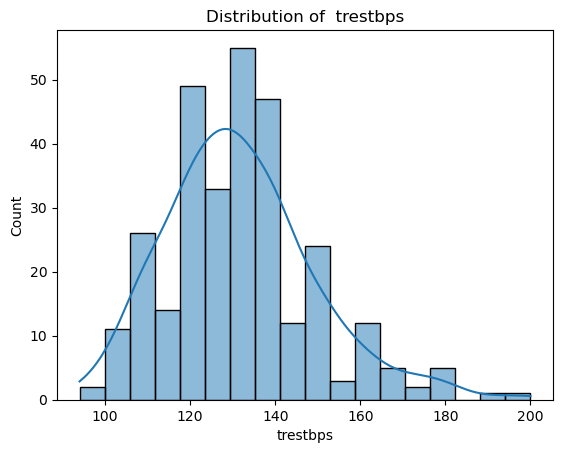

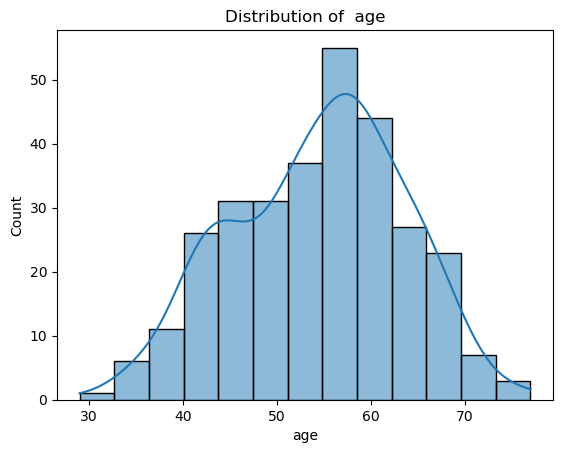

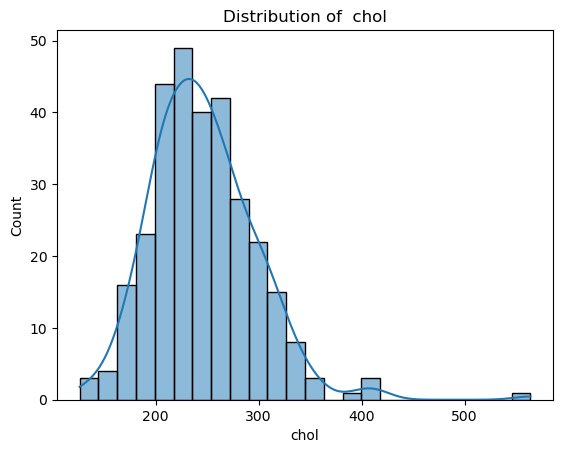

In [57]:
for feature in features:
    sns.histplot(df[feature] , kde=True)
    plt.title(f'Distribution of  {feature}')
    plt.show()

In [58]:
# Checking outliers 

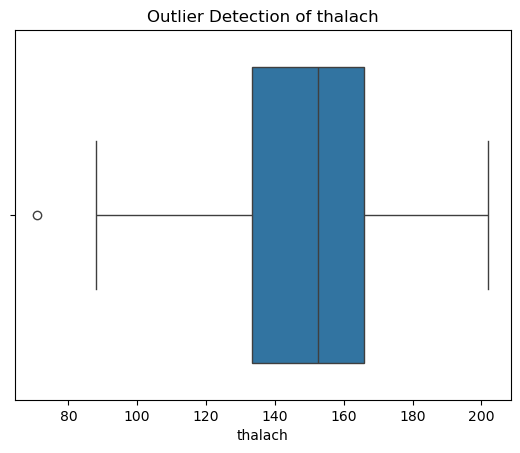

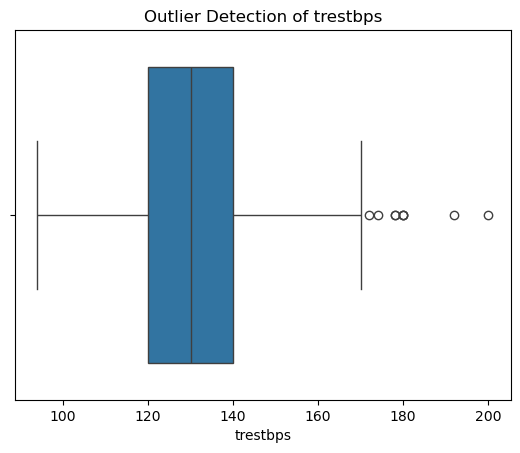

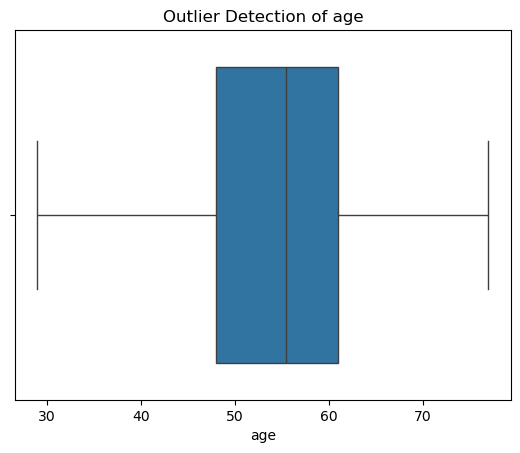

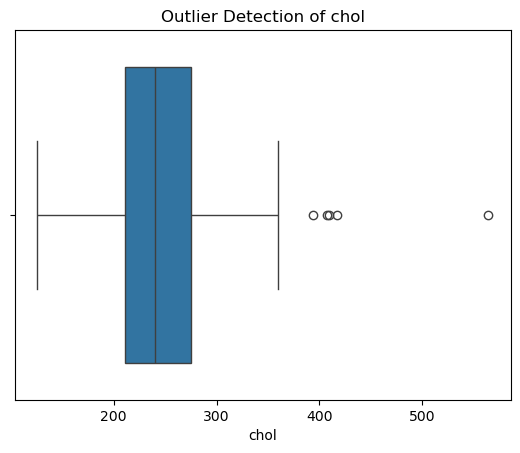

In [59]:
for feature in features:
    sns.boxplot(x=df[feature])
    plt.title(f'Outlier Detection of {feature}')
    plt.show()

In [60]:
# Checking Relation between Features 

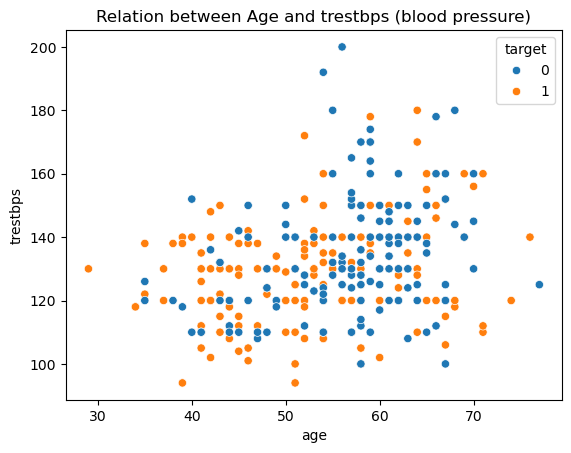

In [61]:
sns.scatterplot(x=df["age"] , y=df["trestbps"] ,hue=df["target"])
plt.title("Relation between Age and trestbps (blood pressure)")
plt.show()

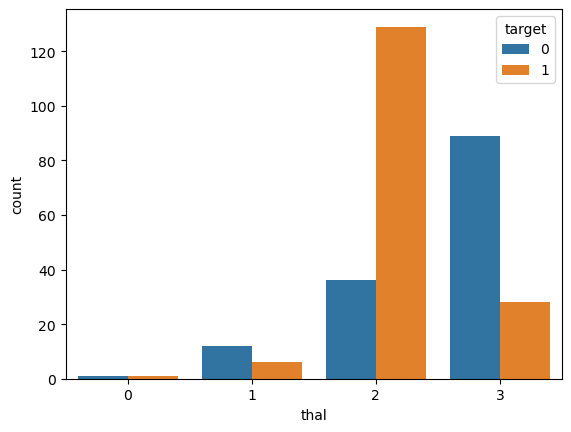

In [62]:
sns.countplot(x=df["thal"], data=df, hue=df["target"])
plt.show()

In [63]:
# Those who had thalesmia of type fixed defect has high heart disease

#### Checking Correlation between features and target

In [64]:
corr = df.corr()

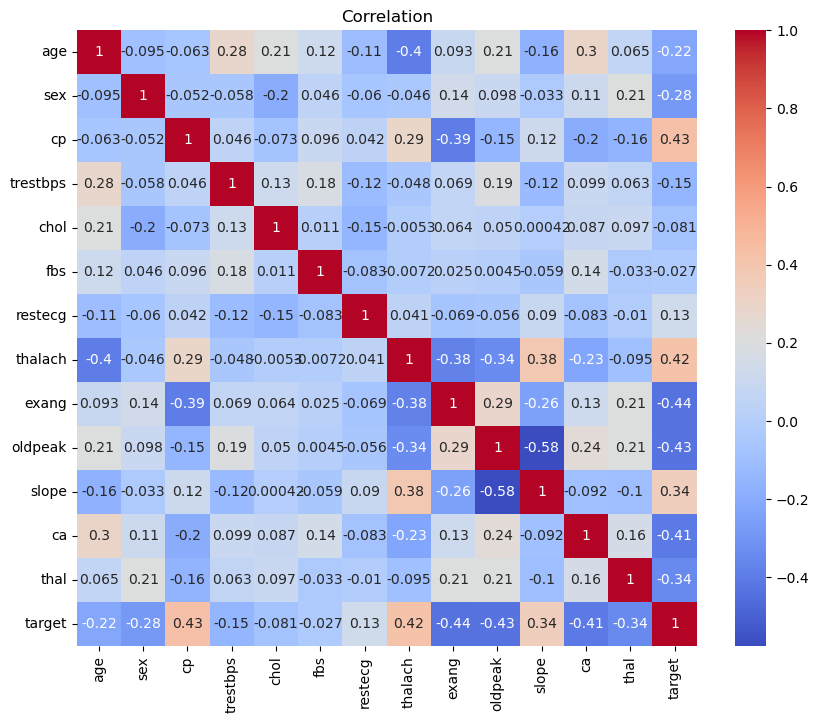

In [65]:
# Visualizing 
plt.figure(figsize=(10,8))
sns.heatmap(corr , annot=True , cmap="coolwarm")
plt.title("Correlation")
plt.show()

## 3) PREPROCESSING

In [66]:
X =df.drop('target' , axis=1)
Y = df['target']

In [67]:
X_train , X_test , y_train, y_test = train_test_split(X,Y , test_size=0.2 , random_state=42 )

In [69]:

Models = {
    "Lr_model": LogisticRegression(class_weight='balanced'),
    "Dt": DecisionTreeClassifier(random_state=42 , class_weight='balanced'),
    "RF": RandomForestClassifier(random_state=42 , class_weight='balanced'),
    "KNN":KNeighborsClassifier()
    
}



results = []

for name, model in Models.items():
    
    # Pipeline
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    # Train
    pipe.fit(X_train, y_train)
    
    # Train Accuracy
    train_pred = pipe.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)
    
    # Test Accuracy
    test_pred = pipe.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    
    # Cross Validation
    cv_scores = cross_val_score(pipe, X, Y, cv=5, scoring="accuracy")
    cv_mean = cv_scores.mean()
    
    results.append([name, train_acc, test_acc, cv_mean])



results_df = pd.DataFrame(
    results,
    columns=["Model", "Train Accuracy", "Test Accuracy", "CV Mean Accuracy"]
)

print(results_df)

      Model  Train Accuracy  Test Accuracy  CV Mean Accuracy
0  Lr_model        0.863071       0.836066          0.827760
1        Dt        1.000000       0.786885          0.738142
2        RF        1.000000       0.868852          0.834317
3       KNN        0.863071       0.918033          0.821038


#### Random Forest shows the best generalization because it maintains high test accuracy (86.8%) and a CV mean (83.4%) close to test performance, indicating good stability without severe overfitting

## 4) HYPERTUNNING 

In [70]:
pipeline = Pipeline([
    ("rf", RandomForestClassifier(random_state=42))
])


param_grid = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [None, 5, 10, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)


grid_search.fit(X_train, y_train)


best_rf_model = grid_search.best_estimator_


y_pred = best_rf_model.predict(X_test)

print("Best Parameters:\n", grid_search.best_params_)
print("Train Accuracy:", best_rf_model.score(X_train, y_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters:
 {'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}
Train Accuracy: 0.983402489626556
Test Accuracy: 0.8852459016393442

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.90      0.88        29
           1       0.90      0.88      0.89        32

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



Confusion Matrix:

 [[26  3]
 [ 4 28]]


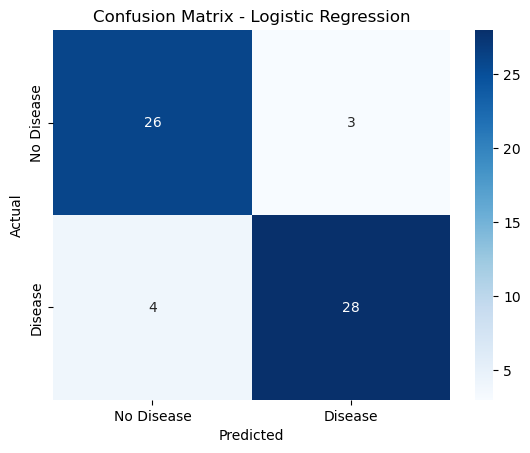

In [71]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n\n", cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

####  Now the tunned model is performing well also the recall for both class is balance now its time to save it

## SAVING 

In [79]:
# Save the trained Random Forest model
joblib.dump(best_rf_model, "rf_heart_model.pkl")

['rf_heart_model.pkl']